# Creating a GHZ state with topology in mind

Today we're discussing transpilation, which, roughly speaking, amounts to choosing which physical qubits to use and how to route circuits in a way which is compatible with the physical hardware. We'll explore this topic by constructing the GHZ state on IQM Resonance!

In [1]:
!pip install --upgrade pip
!pip install qrisp[iqm] matplotlib pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 25.9 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 62.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 96.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.1/81.1 MB 81.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 162.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 139.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 121.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 178.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 87.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 1. Preparation

### 1.1 Connecting to the QPU
First, we need to define the QPU we want to work with by creating a backend object. In order to access the system, you will need the correct url and token.

We're going to be using some functions from Qiskit for this lab, so the connection to the quantum computer looks a little different than we've seen in previous exercises.

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np

from iqm.qrisp_iqm import IQMBackend, create_iqm_pass_manager
from qrisp import QuantumVariable, h, p, cx, manual_layout, measure, barrier

from rustworkx import spring_layout, PyGraph
from rustworkx.visualization import mpl_draw

In [ ]:
token = input("IQM Resonance token: ")

iqm_server_url = os.environ.get("IQM_SERVER_URL", "https://resonance.iqm.tech")
quantum_computer = "emerald"  # Change to appropriate device name

iqm_device = IQMBackend(
    token=token,
    server_url = iqm_server_url,
    device_instance = quantum_computer)


### 1.2 Visualizing the qubits
Now we can access the system and plot its connectivity graph to check that everything is working properly. Each dot represents a qubit and each line represents coupling between those qubits.

Compare this graph to what is shown on the IQM Resonance webpage. What looks the same? What looks different? (Hint: What is the smallest-numbered qubit on each?)

In [ ]:
connectivity = iqm_device.connectivity
graph = PyGraph()
graph.extend_from_edge_list(connectivity)

mpl_draw(graph, arrows=False, with_labels=True, node_color='#32a8a4', pos=spring_layout(graph, num_iter=200))

## 2. Creating a GHZ state

The GHZ (Greenberger-Horne-Zeilinger) state is a maximally entangled quantum state that involves three or more qubits. It is an equal superposition of all qubits being in state 0 and all qubits being in state 1. We will first use 3 qubits of the 54 we have available on the system; this can be represented as:

$$\frac{1}{\sqrt{2}}(∣000⟩+ ∣111⟩)$$

In order to create a GHZ state, we follow the steps below:

<ol>
<li> First, we initiate the process by <b>creating a superposition</b> using a Hadamard gate <span style="    display: inline-block; min-width: 1.7rem; text-align: center; background: linear-gradient(0.45turn, rgba(255, 255, 255, 0.1), rgba(0, 0, 0, 0.05)) rgb(80, 90, 98); color: white; padding: 0.1rem; margin: 0.05rem; font-weight: 600; border-radius: 0.2rem;">H</span> on a qubit.
</li>
<li>  Then, we <b>apply <span style="display: inline-block; min-width: 1.7rem; text-align: center; background: linear-gradient(0.45turn, rgba(255, 255, 255, 0.1), rgba(0, 0, 0, 0.05)) rgb(80, 90, 98); color: white; padding: 0.1rem; margin: 0.05rem; font-weight: 600; border-radius: 0.2rem;">CNOT</span> gates from one qubit to two other qubits</b>.
</li>
<li> Finally, we perform <b>measurements on all qubits.
</li>
</ol>

In [ ]:
num_qb = 3

qv = QuantumVariable(num_qb)

#TODO: implement the above circuit



measure(qv)

print(qv.qs)


Executing it is then simply a matter of running the circuit on the backend.

In [ ]:
shots = 1000
job = qv.get_measurement(backend=iqm_device, shots=shots)

plt.bar(list(map(str,job.keys())), job.values())
plt.xlabel("Measurement outcomes")
plt.ylabel("Probability")
plt.show()

## 3. Creating the GHZ state on a different set of qubits

When running a circuit with fewer qubits than available, we have the possibility to choose the most performant qubits in the QPU.

**Task: Fill in and execute the two code blocks below to create a GHZ state on two different sets of qubits.**

Use the topology of the system to choose a more efficient set of qubits for a GHZ states. Execute them on the real quantum computer and compare the outcomes.

In [ ]:
manual_qubits_1 = [
    #Labels for the qubits that we're going to use.
    #NOTE: Qubits on the machine are 1-indexed, but qubits in Qrisp are 0-indexed!
    #So qubit 15 on Garnet is index 14 in Qrisp!
    0,1,4
]

manual_qubits_2 = [
#TODO: Pick another set of 3 qubits, ideally the best-performing ones that you can!

]

# Shows the couplings between the qubits we have selected without showing any of the others.

reduced_coupling_1 = [pair for pair in connectivity if pair[0] in manual_qubits_1 and pair[1] in manual_qubits_1]
reduced_coupling_2 = [pair for pair in connectivity if pair[0] in manual_qubits_2 and pair[1] in manual_qubits_2]
print("Reduced coupling map, set 1: ", reduced_coupling_1)
print("Reduced coupling map: ", reduced_coupling_2)

Keep in mind the reduced coupling maps above to choose on which qubit you should apply the Hadamard and the CNOT gates.

Below we customize the Qrisp transpiler to include the manual qubit selection:

In [ ]:
# Create a transpiler
pm_1 = create_iqm_pass_manager(iqm_device.connectivity)
pm_2 = create_iqm_pass_manager(iqm_device.connectivity)

# Remove the automatic qubit selection. If you run print(pm_1), you can see the
# list of different pieces of the process; we want to remove the plasma_layout pass.
pm_1.remove_pass(7)
pm_2.remove_pass(7)

# Add manual qubit selection. We're making this the first thing the transpiler
# does; that won't cause problems.
pm_1.insert_pass(0,manual_layout(manual_qubits_1))
pm_2.insert_pass(0,manual_layout(manual_qubits_2))

# Actually transpile and print the circuits
qc1_transpiled = pm_1.run(qv.qs)
qc2_transpiled = pm_2.run(qv.qs)
print(qc1_transpiled)
print(qc2_transpiled)

Finally, run the next two cells to run both circuits on Resonance and compare the results.

In [ ]:
shots = 1000
job1 = qc1_transpiled.run(backend=iqm_device, shots=shots)

plt.bar(list(map(str,job1.keys())), job1.values())
plt.xlabel("Measurement outcomes")
plt.ylabel("Probability")
plt.show()

In [ ]:
shots = 1000
job2 = qc2_transpiled.run(backend=iqm_device, shots=shots)

plt.bar(list(map(str,job2.keys())), job2.values())
plt.xlabel("Measurement outcomes")
plt.ylabel("Probability")
plt.show()

## 4. Homework: Making a big GHZ state with good routing

If we try making a GHZ state with more than 5 qubits, we are going to run into routing problems. Why?

If you look at the coupling map, you will notice that no qubit is connected to more than 4 other qubits. If you look back at the circuit we implemented above, it applies CNOT between one qubit and `num_qubits`-1 other qubits. This means that we have a routing problem if `num_qubits > 5`.

An important fact is that if we have a GHZ state of $n$ qubits, we can make a bigger GHZ state with $n+1$ qubits by applying a CNOT gate between *any* qubit in the smaller GHZ state and a new qubit. For example, the following two circuits both create a 3-qubit GHZ state:

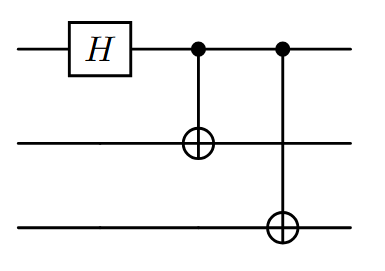

and

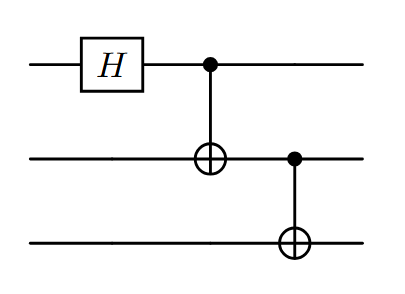

We're going to compare making a big GHZ state the old way and a more efficient way. First, let's write the circuit for the old way:

In [ ]:
# Make the big GHZ state the old way
num_qb = 9

big_GHZ = QuantumVariable(num_qb)

h(big_GHZ[0])
for qb in range(1, num_qb):
    cx(big_GHZ[0], big_GHZ[qb])

barrier(big_GHZ)

measure(big_GHZ)
print(big_GHZ.qs)

In the cell below, create a 9-qubit GHZ state in a well-routed way. Choose the gates and qubits carefully so that all of the gates are between qubits connected by a coupler.

In [ ]:
efficient_GHZ = QuantumVariable(9)

# TODO: create a 9-qubit state in a way that works with routing
pass






barrier(efficient_GHZ) # make circuit visualization a little prettier
measure(efficient_GHZ)

my_nine_qubits = [
    # TODO: add labels for the qubits that we're going to use. The qubit you list first will correspond to big_GHZ_state[0], the second will be
    #   big_GHZ_state[1], and so on.
]

# Draw the circuit. Since we haven't transpiled it yet, it won't use the physical qubits in the drawing, just qubits 0 through 8.
print(efficient_GHZ.qs)


Now we transpile both circuits on the same 9 qubits that you chose:

In [ ]:
pm = create_iqm_pass_manager(iqm_device.connectivity)

pm.remove_pass(7)

pm.insert_pass(0,manual_layout(my_nine_qubits))

inefficient_transpiled = pm.run(big_GHZ.qs)
efficient_transpiled = pm.run(efficient_GHZ.qs)

In [ ]:
print(inefficient_transpiled)

In [ ]:
print(efficient_transpiled)

Finally, run both on the quantum computer and compare the results.

In [ ]:
shots = 10000
inefficient_job = inefficient_transpiled.run(backend=iqm_device, shots=shots)

plt.bar(list(map(str,inefficient_job.keys())), inefficient_job.values())
plt.xlabel("Measurement outcomes")
plt.ylabel("Probability")
plt.show()

In [ ]:
efficient_job = efficient_transpiled.run(backend=iqm_device, shots=shots)

plt.bar(list(map(str,efficient_job.keys())), efficient_job.values())
plt.xlabel("Measurement outcomes")
plt.ylabel("Probability")
plt.show()

## 5. For the curious: Verifying genuine multi-qubit entanglement by measuring the GHZ state fidelity

The GHZ state fidelity $F$ is a quantity that acts as a witness for genuine multi-qubit entanglement. That is, it can be mathematically proven that if $F$ is larger than 0.5, then the measurement results cannot be explained without entanglement involving all qubits (more precisely, it has been shown that this is equivalent to measuring a negative expectation value of a multipartite entanglement witness - see [Mooney, 2021](https://iopscience.iop.org/article/10.1088/2399-6528/ac1df7/meta) and references therein). This means that $F$ is a great way to evaluate the "quantumness" of the computer.

The fidelity of a mixed state is computed using the [formula](https://en.wikipedia.org/wiki/Fidelity_of_quantum_states)
$$F(\text{ideal}, \text{measured})= \left(\text{Tr}\sqrt{\sqrt{\rho_{\text{ideal}}}\rho_{\text{measured}}\sqrt{\rho_{\text{ideal}}}}\right)^2$$

where $\rho_{\text{ideal}}$ is the density matrix of an ideal GHZ state (i.e. without noise) and $\rho_{\text{measured}}$ is the density matrix as given by the actual results of the quantum computer. The ideal GHZ state density matrix only has non-zero entries in the four corners of the density matrix $|00...0\rangle\langle00...0|$, $|00...0\rangle \langle11...1|$, $|11...1\rangle \langle00...0|$, $|11...1\rangle \langle11...1|$. This simplifies the process since we only need to measure these four components. In the fidelity formula, all other entries are effectively nullified by the zero entries in the ideal state matrix.

From the experiment above we obtained the diagonal elements of $\rho_{\text{measured}}$, but we still need to measure the coherences along the anti-diagonal. We will use the method of multiple quantum coherences to measure these off-diagonal entries [Mooney, 2021](https://iopscience.iop.org/article/10.1088/2399-6528/ac1df7/meta).

This method leverages the fact that for a GHZ state, a phase rotation $e^{i\phi}$ applied to all $n$ qubits results in the $|11...1\rangle$ component acquiring a cumulative phase of $e^{in\phi}$. The $|00...0\rangle$ component remains unaffected by this phase rotation and does not accumulate any phase. To measure this, we generate a GHZ state, apply phase shifts to all qubits, and then attempt to reverse the state using the circuit that initially created the GHZ state. From this, we can then observe the oscillation of the probability of the $|00...0\rangle$ component as we scan the phase angle from $0$ to $2\pi$. By fourier transforming the signal we can extract the amplitude of the oscillation happening at frequency $n$, which is a measure of the $|00...0\rangle \langle11...1|,|11...1 \rangle \langle00...0|$ coherences.

In order to perform these measurements, we first need to generate the phase-shifter circuits used in the method of multiple quantum coherences. We will create $2n+2$ of these circuits, which is the maximal step-size for detecting a signal oscillating at frequency $n$ according to the [Nyquist–Shannon sampling theorem](https://en.wikipedia.org/wiki/Nyquist%E2%80%93Shannon_sampling_theorem).

In [ ]:
phases=[np.pi*i/(num_qb +1) for i in range(2*num_qb+2)] # Creating phase shifts at intervals 1/(2n+2)

circuits=[]
for phase in phases:
    qv = QuantumVariable(num_qb)

    # Creating a GHZ state
    h(qv[0])
    for qb in range(1, num_qb):
        cx(qv[0], qv[qb])

    barrier(qv[0])
    #adding phases
    for i in range(num_qb):
        p(phase,qv[i])
    barrier(qv)

    # Undoing GHZ can be acchieved by applying the same operations as above in reverse order
    for qb in range(1, num_qb):
        cx(qv[0], qv[num_qb - qb])
    h(qv[0])

    #measure
    measure(qv)
    circuits.append(qv.qs)

# Draw a circuit as an example
print(circuits[1])

Now we are ready to send our circuits to the quantum computer. Instead of sending them individually, we can send them all at once in a single batch for faster execution. A batch is a list that contains several circuits and, under most circumstances, is more time-efficient.

In [ ]:
batched_device = iqm_device.batched()

plain_GHZ = batched_device.run(big_GHZ.qs,shots=10000) # When sending a batch of circuits, this will NOT execute the circuits!
                                                       # We can add more circuits if we want before executing.

all_counts = batched_device.run(circuits, shots=10000)
batched_device.dispatch() # This will actually execute the circuits.

With our job completed, we can collect the results from the system and use them to calculate the coherences and the fidelity of the GHZ state.

In [ ]:
all_zero_probability_list=[] # An ordered list for storing the probabilites of returning to the |000> state

for count in all_counts:
    probability = count['0'*num_qb]/shots
    all_zero_probability_list.append(probability)

# Computing the phase acquired by the |111> component for each interval
complex_coefficients = np.exp(1j*num_qb*np.array(phases))

# Extracting coherence parameter i_n using the Fourier transform
i_n = np.abs(np.dot(complex_coefficients,np.array(all_zero_probability_list)))/(len(phases))

# Extracting the probabilites of the 000 and 111 bitstrings
# from the results of point 2 of this notebook
probs_direct = {label: count / shots for label, count in plain_GHZ.items()}

# Computing GHZ state fidelity from i_n and the probabilites according to the method in [Mooney, 2021]
fidelity=(probs_direct['0'*num_qb]+probs_direct['1'*num_qb] + 2 * np.sqrt(i_n))/2

print("Measured GHZ Fidelity = " + str(fidelity))

Is the result higher or lower than $0.5$?
A fidelity of $0.5$ would be sufficient for certifying the "quantumness" of the device through genuine multi-qubit entanglement: The measurement results cannot be explained through fewer then 3 qubits entangled.

**Task: Adapt the code cells above and create a GHZ state with more qubits and measure its fidelity. If the result is higher than $0.5$, keep going - make the biggest GHZ state that can is certifiably "quantum."**

In [ ]:
# Copyright 2024 IQM Quantum Computers (Hermanni Heimonen, Stefan Seegerer, Stefan Pogorzalek, Nadia Milazzo)
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.